In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# Loading the dataset
df = pd.read_csv('/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')

In [37]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [38]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [39]:
df.shape

(301, 9)

In [40]:
df.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [42]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [43]:
from os import dup
#data quality check
duplicate_count = df.duplicated().sum()
print('Duplicate Rows',duplicate_count)

Duplicate Rows 2


In [44]:
df = df.drop_duplicates().copy()
print('Duplicates remaining',df.duplicated().sum())

Duplicates remaining 0


In [45]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]
missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


In [47]:
# Categorical columns: missing means we do not know the category
categorical_columns = [
    'Car_Name',
    'Fuel_Type',
    'Seller_Type',
    'Transmission',
    'Owner'
]

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')

In [50]:
# Numerical columns: fill missing values with the median
numerical_columns = [
    'Year',
    'Selling_Price',
    'Present_Price',
    'Kms_Driven'
]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [49]:
# Selling price is important for analysis,
# so remove rows where selling price is missing.
df = df.dropna(subset=['Selling_Price']).copy()

In [48]:
# Standardize fuel type values
df['Fuel_Type'] = df['Fuel_Type'].replace({
    'Petrol ': 'Petrol',
    'Diesel ': 'Diesel',
    'CNG ': 'CNG'
})

# Check the counts of each fuel type
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,58
CNG,2


In [51]:
# Replace invalid car year values with NaN
df.loc[~df['Year'].between(1900, 2026), 'Year'] = np.nan

# Replace invalid kilometers driven values with NaN
df.loc[df['Kms_Driven'] < 0, 'Kms_Driven'] = np.nan

# Fill missing values with the median
df['Year'] = df['Year'].fillna(df['Year'].median())

df['Kms_Driven'] = df['Kms_Driven'].fillna(df['Kms_Driven'].median())

In [52]:
# Numerical columns where median imputation is reasonable for this exercise.

df['Year'] = df['Year'].fillna(df['Year'].median())

df['Selling_Price'] = df['Selling_Price'].fillna(
    df['Selling_Price'].median()
)

df['Present_Price'] = df['Present_Price'].fillna(
    df['Present_Price'].median()
)

df['Kms_Driven'] = df['Kms_Driven'].fillna(
    df['Kms_Driven'].median()
)

In [53]:
missing_after = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing_after = missing_after[missing_after['Missing Count'] > 0]

missing_after.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


In [54]:
# Analyze

fuel_counts = df['Fuel_Type'].value_counts()

fuel_counts

,count
Fuel_Type,
Petrol,239
Diesel,58
CNG,2


In [55]:
seller_counts = df['Seller_Type'].value_counts()

seller_counts

,count
Seller_Type,
Dealer,193
Individual,106


In [56]:
average_price = df['Selling_Price'].mean()

median_price = df['Selling_Price'].median()

print(f'Average selling price: ₹{average_price:,.2f} lakh')
print(f'Median selling price: ₹{median_price:,.2f} lakh')

Average selling price: ₹4.59 lakh
Median selling price: ₹3.51 lakh


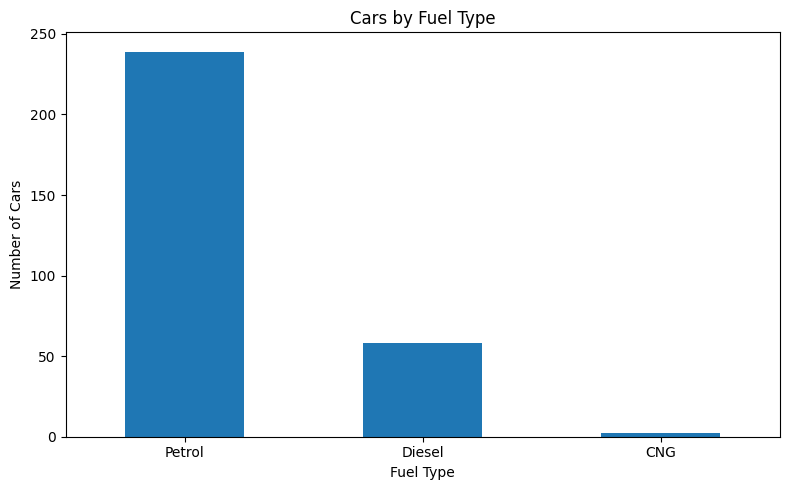

In [57]:
# Chart 1: Cars by Fuel Type
plt.figure(figsize=(8, 5))
fuel_counts.plot(kind='bar')

plt.title('Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

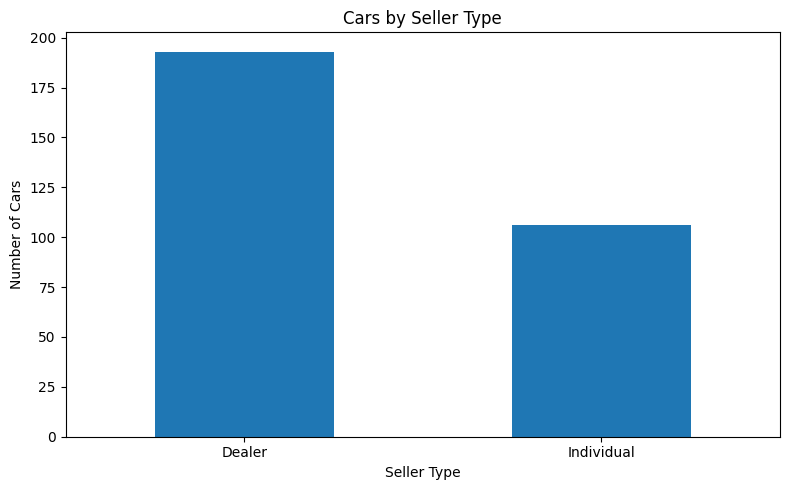

In [58]:
# Chart 2: Cars by Seller Type
plt.figure(figsize=(8, 5))

seller_counts.plot(kind='bar')

plt.title('Cars by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Number of Cars')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

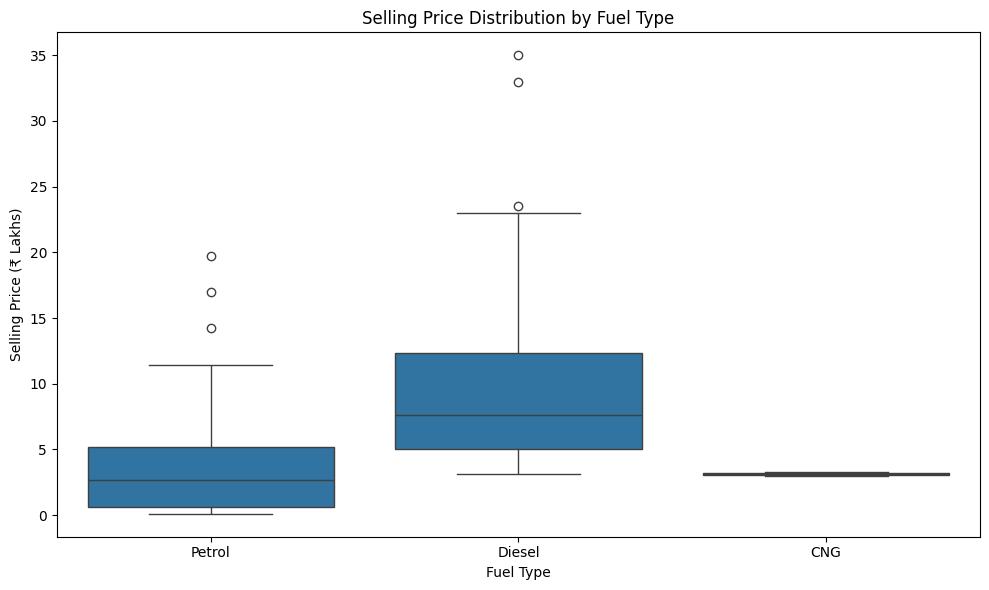

In [59]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)

plt.title('Selling Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (₹ Lakhs)')

plt.tight_layout()

plt.show()

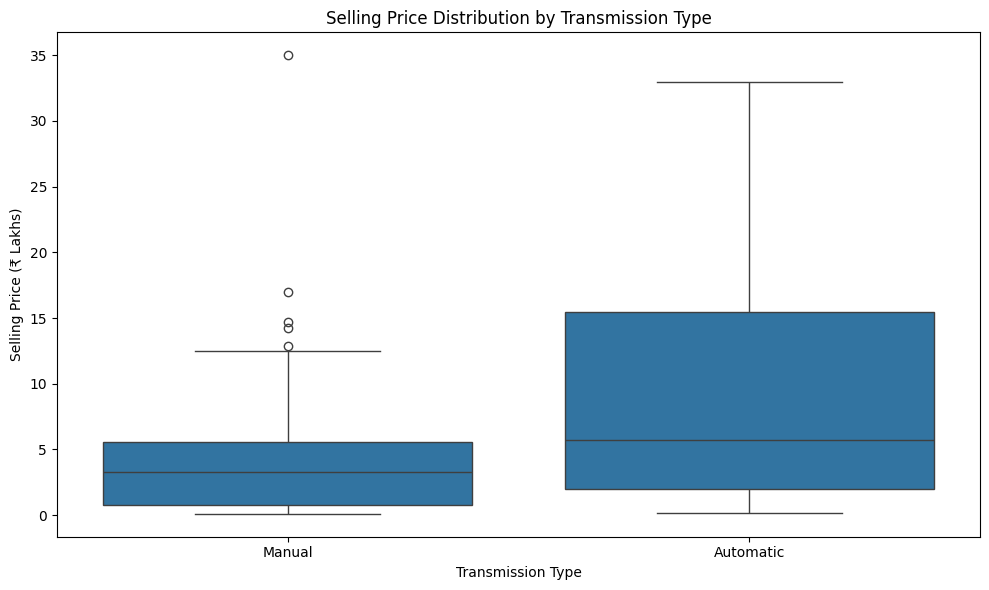

In [60]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Transmission', y='Selling_Price', data=df)
plt.title('Selling Price Distribution by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price (₹ Lakhs)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

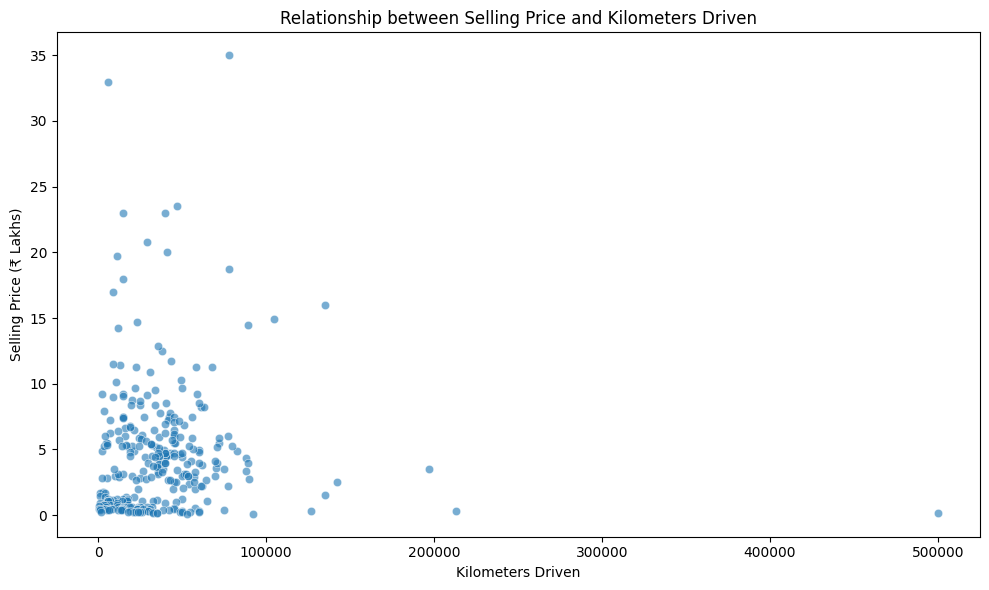

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Kms_Driven', y='Selling_Price',data=df, alpha=0.6)
plt.title('Relationship between Selling Price and Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (₹ Lakhs)')
plt.tight_layout()
plt.show()

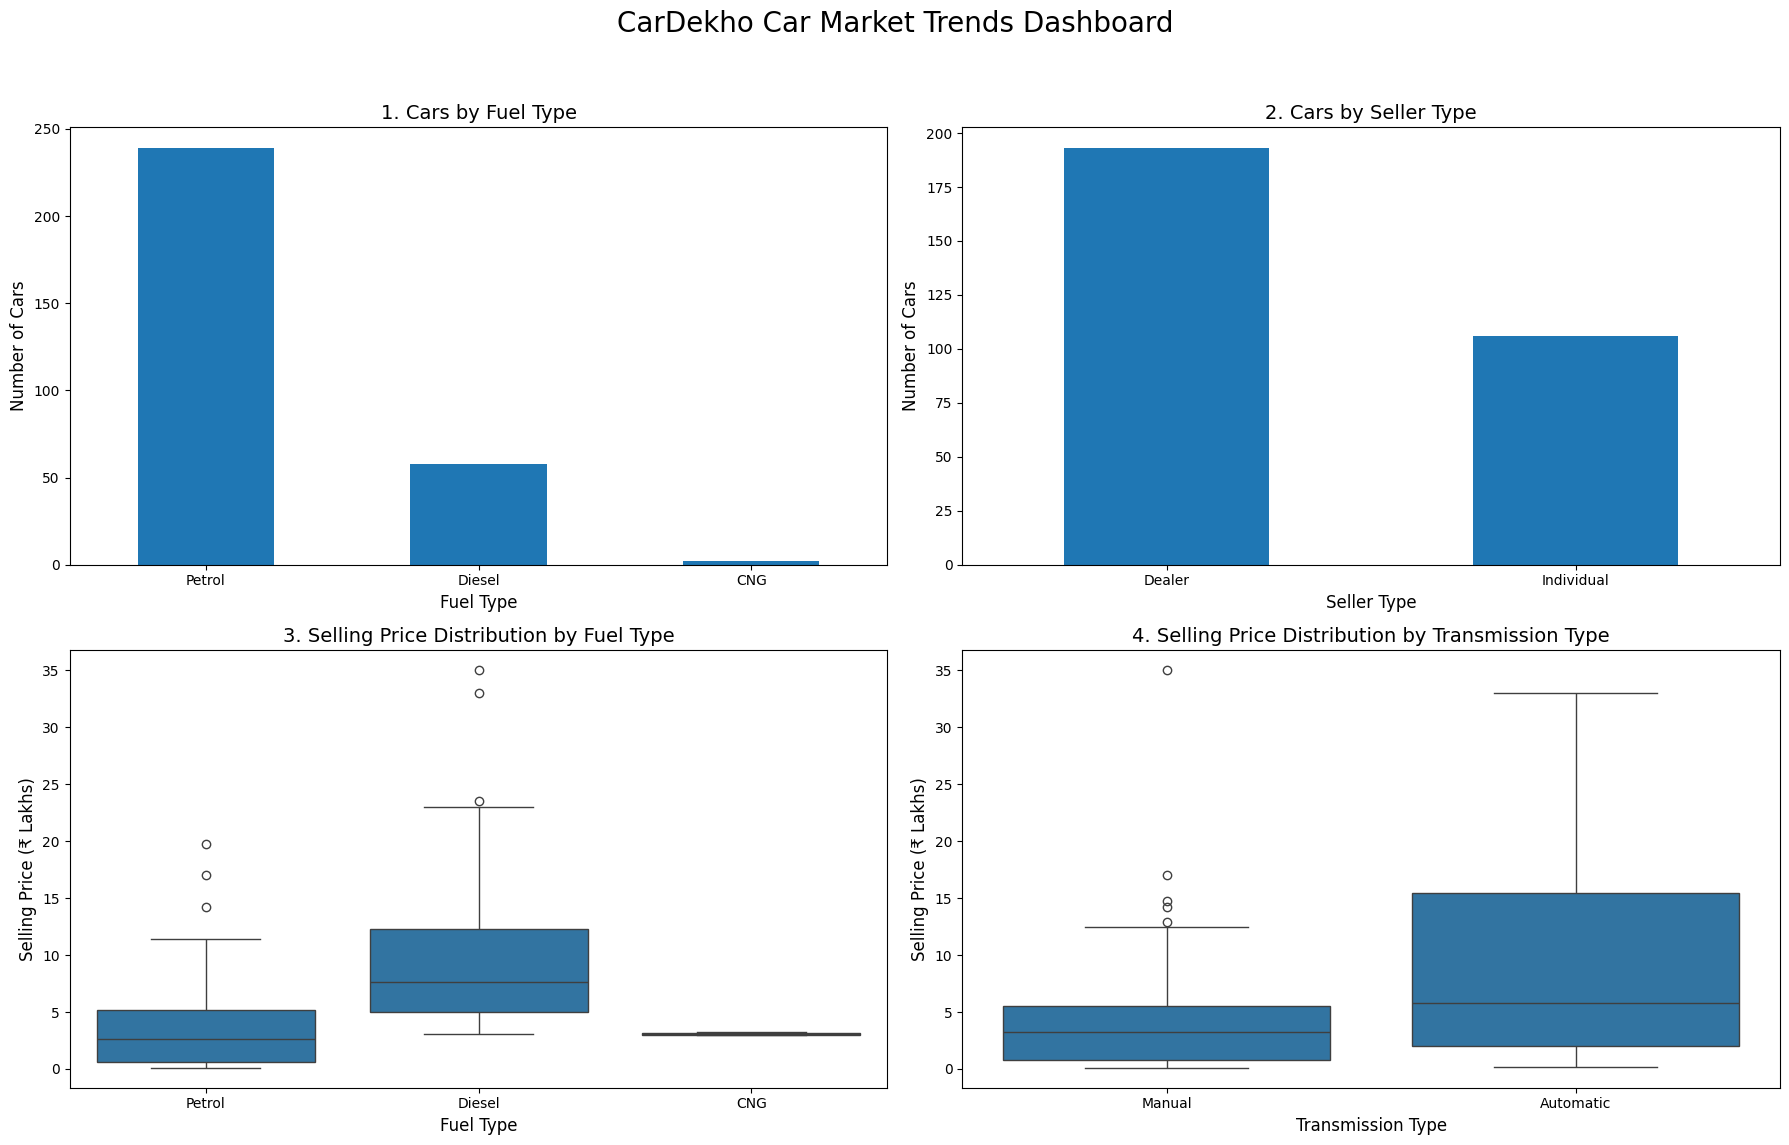

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('CarDekho Car Market Trends Dashboard', fontsize=20)
fuel_counts.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('1. Cars by Fuel Type', fontsize=14)
axes[0, 0].set_xlabel('Fuel Type', fontsize=12)
axes[0, 0].set_ylabel('Number of Cars', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=0)
seller_counts.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('2. Cars by Seller Type', fontsize=14)
axes[0, 1].set_xlabel('Seller Type', fontsize=12)
axes[0, 1].set_ylabel('Number of Cars', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=0)
sns.boxplot(
    x='Fuel_Type',
    y='Selling_Price',data=df,ax=axes[1, 0])
axes[1, 0].set_title(
    '3. Selling Price Distribution by Fuel Type',
    fontsize=14
)
axes[1, 0].set_xlabel('Fuel Type', fontsize=12)
axes[1, 0].set_ylabel('Selling Price (₹ Lakhs)', fontsize=12)
sns.boxplot(
    x='Transmission',
    y='Selling_Price',
    data=df,
    ax=axes[1, 1]
)
axes[1, 1].set_title(
    '4. Selling Price Distribution by Transmission Type',
    fontsize=14
)
axes[1, 1].set_xlabel('Transmission Type', fontsize=12)
axes[1, 1].set_ylabel('Selling Price (₹ Lakhs)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()